## training a CNN to classify hand-written digits in the MNIST dataset

In [1]:
import torch, os
import torchvision
import matplotlib.pyplot as plt
import numpy as np 
%matplotlib inline

In [2]:
# defining hyperparameters 

n_epochs = 3            # how many times we are going to loop through the complete training dataset 
batch_size_train = 64
batch_size_test = 1000
learning_rate = 1e-2
momentum = 0.5
log_interval = 10

random_seed = 1
torch.manual_seed(random_seed)

# Set the device. CUDA if available, CPU otherwise
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print('GPU available')
else:
    print('running on CPU')

GPU available


In [3]:
resultsPath = 'results/2_CNN_4_mnist'

if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

In [4]:
train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(
        'data', train=True, download=False,
        transform=torchvision.transforms.Compose([
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(
                (0.1307, ), (0.3081, )
            )
        ])
    ), batch_size = batch_size_train, shuffle=True
)

In [5]:
test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(
        'data', train=False, download=False,
        transform=torchvision.transforms.Compose([
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(
                (0.1307, ), (0.3081, )
            )
        ])
    ), batch_size = batch_size_test, shuffle=True
)

In [6]:
examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

In [7]:
batch_idx

0

In [8]:
len(example_data)

64

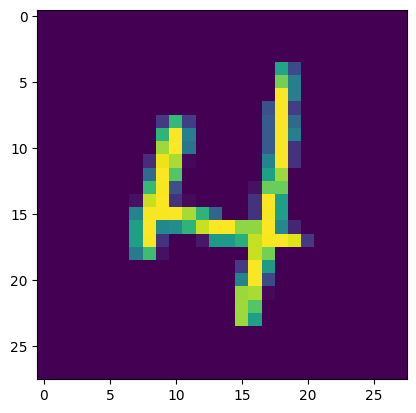

In [9]:
plt.imshow(example_data[0].squeeze())
plt.show()

In [10]:
example_targets

tensor([4, 8, 8, 6, 7, 1, 0, 7, 1, 8, 7, 6, 4, 9, 1, 5, 3, 2, 6, 8, 8, 6, 9, 4,
        6, 0, 4, 2, 6, 7, 0, 5, 8, 6, 0, 3, 5, 7, 4, 7, 5, 1, 6, 7, 3, 6, 0, 3,
        1, 1, 2, 6, 7, 9, 8, 0, 7, 2, 4, 3, 6, 5, 9, 5])

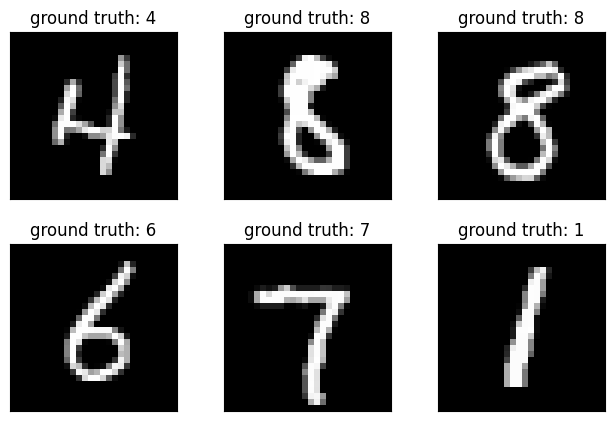

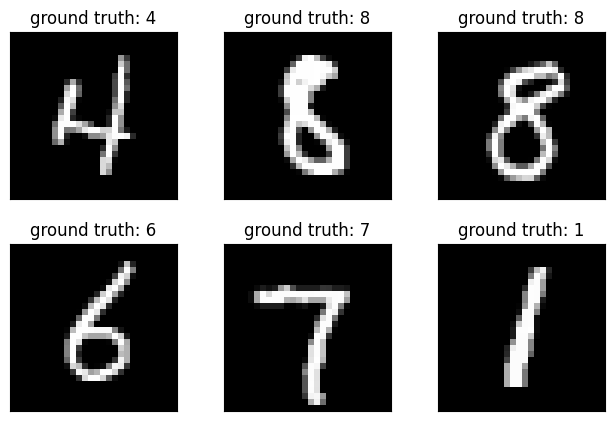

In [11]:
fig = plt.figure()

for i in np.arange(6):
    plt.subplot(2, 3, i+1)
    plt.tight_layout()
    plt.imshow(example_data[i].squeeze(), cmap='gray')
    plt.title(f'ground truth: {example_targets[i]}')
    plt.xticks([])
    plt.yticks([])

fig

In [12]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [13]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x)


In [14]:
network = Net().to(device)
optimizer = optim.SGD(network.parameters(), lr = learning_rate, momentum=momentum)

In [15]:
train_losses = []
train_counter = []
test_losses = []
test_counter = [i * len(train_loader.dataset) for i in np.arange(n_epochs + 1)]

In [16]:
test_counter

[np.int64(0), np.int64(60000), np.int64(120000), np.int64(180000)]

In [17]:
def train(epoch):
    network.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = network(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
        epoch, batch_idx * len(data), len(train_loader.dataset),
        100. * batch_idx / len(train_loader), loss.item()))
            
            train_losses.append(loss.item())
            train_counter.append(
                (batch_idx*batch_size_train) + ((epoch-1)*len(train_loader.dataset))
            )
            torch.save(network.state_dict(), f'{resultsPath}/model.pth')
            torch.save(optimizer.state_dict(), f'{resultsPath}/optimizer.pth')


In [18]:
def test():
    network.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = network(data)
            test_loss += F.nll_loss(output, target, size_average=False).item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).sum()
        test_loss /= len(test_loader.dataset)
        test_losses.append(test_loss)
        print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
    test_loss, correct, len(test_loader.dataset),
    100. * correct / len(test_loader.dataset)))

In [19]:
test()
for epoch in np.arange(1, n_epochs+1):
    train(epoch=epoch)
    test()

/tmp/ipykernel_703527/2490208733.py:17: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)
/home/jxiang27/ai4fun/lib/python3.12/site-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))



Test set: Avg. loss: 2.3096, Accuracy: 924/10000 (9%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.331797
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.303324
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.266475
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.272787
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.261453
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.231299
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.225890
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.222582
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.114449
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.042786
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.954830
Train Epoch: 1 [7040/60000 (12%)]	Loss: 1.993546
Train Epoch: 1 [7680/60000 (13%)]	Loss: 1.804038
Train Epoch: 1 [8320/60000 (14%)]	Loss: 1.503693
Train Epoch: 1 [8960/60000 (15%)]	Loss: 1.450857
Train Epoch: 1 [9600/60000 (16%)]	Loss: 1.507668
Train Epoch: 1 [10240/60000 (17%)]	Loss: 1.313455
Train Epoch: 1 [10880/60000 (18%)]	Loss: 1.363018
Train Epoch: 1 [11520/60000 (19%)]	Loss: 1.437640
Train Epoch: 1 [12160/6

Text(0, 0.5, 'negative log likelihood loss')

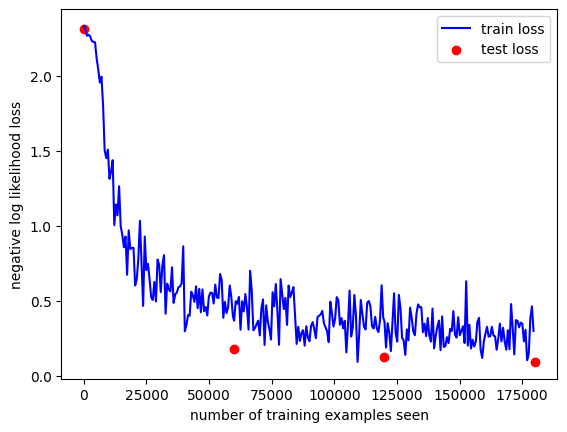

In [20]:
fig = plt.figure()
plt.plot(train_counter, train_losses, color='blue')
plt.scatter(test_counter, test_losses, color='red')
plt.legend(['train loss', 'test loss'], loc='upper right')
plt.xlabel('number of training examples seen')
plt.ylabel('negative log likelihood loss')

In [21]:
with torch.no_grad():
    output = network(example_data.to(device))

/tmp/ipykernel_703527/2490208733.py:17: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


In [22]:
output.shape

torch.Size([64, 10])

In [23]:
output.data.max(1, keepdim=True)[1]

tensor([[4],
        [8],
        [8],
        [6],
        [7],
        [1],
        [0],
        [7],
        [1],
        [8],
        [7],
        [6],
        [4],
        [9],
        [1],
        [5],
        [3],
        [7],
        [6],
        [8],
        [8],
        [6],
        [9],
        [4],
        [6],
        [0],
        [4],
        [2],
        [6],
        [7],
        [0],
        [5],
        [8],
        [6],
        [7],
        [6],
        [5],
        [7],
        [4],
        [7],
        [5],
        [1],
        [6],
        [7],
        [3],
        [6],
        [0],
        [3],
        [1],
        [1],
        [2],
        [6],
        [7],
        [9],
        [8],
        [0],
        [7],
        [2],
        [4],
        [3],
        [6],
        [5],
        [9],
        [5]], device='cuda:0')

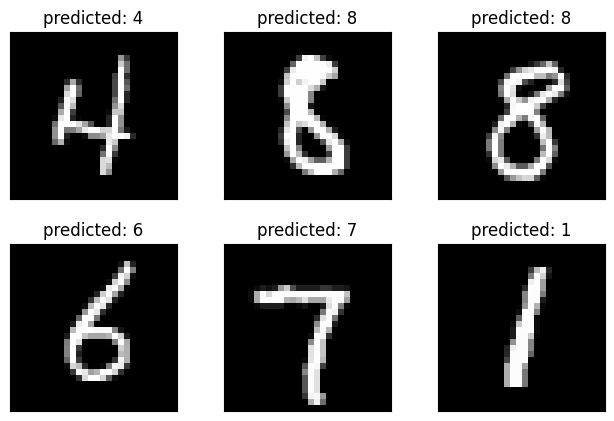

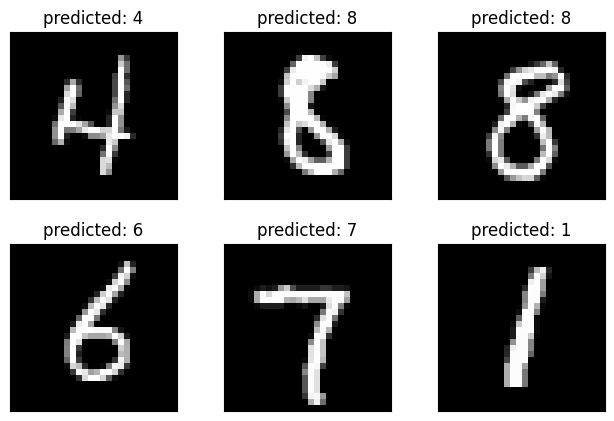

In [24]:
fig = plt.figure()

for i in np.arange(6):
    plt.subplot(2, 3, i+1)
    plt.tight_layout()
    plt.imshow(example_data[i].squeeze(), cmap='gray')
    plt.title(f'predicted: {output.data.max(1, keepdim=True)[1][i].item()}')
    plt.xticks([])
    plt.yticks([])

fig

### continued training from checkpoints

In [25]:
continued_network = Net()
continued_optimizer = optim.SGD(network.parameters(), lr=learning_rate, momentum=momentum)

In [26]:
network_state_dict = torch.load(f'{resultsPath}/model.pth')
continued_network.load_state_dict(network_state_dict)

optimizer_state_dict = torch.load(f'{resultsPath}/optimizer.pth')
continued_optimizer.load_state_dict(optimizer_state_dict)

In [27]:
print(network_state_dict.keys())
network_state_dict['conv1.weight'].shape

odict_keys(['conv1.weight', 'conv1.bias', 'conv2.weight', 'conv2.bias', 'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias'])


torch.Size([10, 1, 5, 5])

In [28]:
for i in np.arange(4, 9):
    test_counter.append(i*len(train_loader.dataset))
    train(i)
    test()

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.127800
Train Epoch: 4 [640/60000 (1%)]	Loss: 0.230234


/tmp/ipykernel_703527/2490208733.py:17: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


Train Epoch: 4 [1280/60000 (2%)]	Loss: 0.278849
Train Epoch: 4 [1920/60000 (3%)]	Loss: 0.254096
Train Epoch: 4 [2560/60000 (4%)]	Loss: 0.197026
Train Epoch: 4 [3200/60000 (5%)]	Loss: 0.291769
Train Epoch: 4 [3840/60000 (6%)]	Loss: 0.535725
Train Epoch: 4 [4480/60000 (7%)]	Loss: 0.326865
Train Epoch: 4 [5120/60000 (9%)]	Loss: 0.237240
Train Epoch: 4 [5760/60000 (10%)]	Loss: 0.161776
Train Epoch: 4 [6400/60000 (11%)]	Loss: 0.331375
Train Epoch: 4 [7040/60000 (12%)]	Loss: 0.245171
Train Epoch: 4 [7680/60000 (13%)]	Loss: 0.359427
Train Epoch: 4 [8320/60000 (14%)]	Loss: 0.233089
Train Epoch: 4 [8960/60000 (15%)]	Loss: 0.190479
Train Epoch: 4 [9600/60000 (16%)]	Loss: 0.469211
Train Epoch: 4 [10240/60000 (17%)]	Loss: 0.403352
Train Epoch: 4 [10880/60000 (18%)]	Loss: 0.199398
Train Epoch: 4 [11520/60000 (19%)]	Loss: 0.157250
Train Epoch: 4 [12160/60000 (20%)]	Loss: 0.408536
Train Epoch: 4 [12800/60000 (21%)]	Loss: 0.444496
Train Epoch: 4 [13440/60000 (22%)]	Loss: 0.204116
Train Epoch: 4 [14080

Text(0, 0.5, 'negative log likelihood loss')

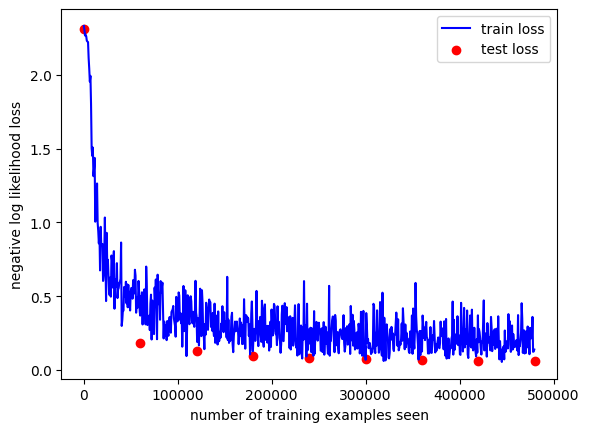

In [29]:
fig = plt.figure()
plt.plot(train_counter, train_losses, color='blue')
plt.scatter(test_counter, test_losses, color='red')
plt.legend(['train loss', 'test loss'], loc='upper right')
plt.xlabel('number of training examples seen')
plt.ylabel('negative log likelihood loss')